# 01 — EDA, обработка данных и подготовка к моделированию

**Задача:** Классификация уровня эмоционального выгорания студентов (`Low` / `Medium` / `High`)  
**Датасет:** [Student Mental Health and Burnout Dataset](https://www.kaggle.com/datasets/sehaj1104/student-mental-health-and-burnout-dataset) — 150 000 записей

### Что делаем в этом ноутбуке:
1. Загрузка и первичный осмотр данных
2. Очистка: пропуски, дубли, выбросы, типы
3. Кодирование категорий
4. Train / Val / Test сплит (стратификация)
5. Сохраняем обработанные данные

In [21]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from src.preprocessing import (
    load_data, basic_info,
    split_raw,              # Step 1: split BEFORE cleaning
    fit_cleaning_stats,     # Step 2a: fit stats on train only
    apply_cleaning,         # Step 2b: apply to every split
    feature_engineering, encode_features, scale_features,
    NUMERIC_COLS, CATEGORICAL_COLS, TARGET_COL
)

os.makedirs('../report/images', exist_ok=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid')
print('Libraries loaded')

Libraries loaded


## 1. Загрузка данных

In [22]:
# Скачать датасет с Kaggle и положить в ../data/raw/student_mental_health_burnout.csv
# Команда для скачивания через Kaggle API:
# kaggle datasets download sehaj1104/student-mental-health-and-burnout-dataset -p ../data/raw/ --unzip

RAW_PATH = '../data/raw/student_mental_health_burnout.csv'
df_raw = load_data(RAW_PATH)
df_raw.head()

Loaded dataset: 150000 rows, 19 columns


,age,gender,course,year,daily_study_hours,daily_sleep_hours,screen_time_hours,stress_level,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,sleep_quality,attendance_percentage,cgpa,internet_quality,burnout_level
0,23,Male,BTech,1st,4.3,6.8,6.1,High,10,3,4,2,6,1.8,Average,66.5,9.63,Good,High
1,20,Male,BTech,3rd,1.4,4.7,3.0,High,2,10,8,5,9,1.9,Poor,55.8,6.04,Poor,Low
2,24,Female,BCA,4th,3.7,4.8,1.5,Low,2,7,8,6,3,0.8,Good,85.0,8.31,Good,High
3,21,Male,BSc,4th,1.6,6.7,7.0,High,3,3,4,9,9,0.7,Poor,89.1,5.95,Good,High
4,23,Other,BSc,4th,2.0,6.7,5.4,High,7,7,6,4,4,1.7,Good,58.7,8.51,Good,Low


In [23]:
# Проверяем реальные названия колонок
print('Columns:', df_raw.columns.tolist())
print('\nShape:', df_raw.shape)

Columns: ['age', 'gender', 'course', 'year', 'daily_study_hours', 'daily_sleep_hours', 'screen_time_hours', 'stress_level', 'anxiety_score', 'depression_score', 'academic_pressure_score', 'financial_stress_score', 'social_support_score', 'physical_activity_hours', 'sleep_quality', 'attendance_percentage', 'cgpa', 'internet_quality', 'burnout_level']

Shape: (150000, 19)


In [24]:
# Если названия колонок отличаются от ожидаемых — переименуй здесь:
# df_raw = df_raw.rename(columns={'Burnout_Level': 'burnout_level', ...})

# Полная базовая информация
basic_info(df_raw)

=== Shape ===
(150000, 19)

=== dtypes ===
age                          int64
gender                      object
course                      object
year                        object
daily_study_hours          float64
daily_sleep_hours          float64
screen_time_hours          float64
stress_level                object
anxiety_score                int64
depression_score             int64
academic_pressure_score      int64
financial_stress_score       int64
social_support_score         int64
physical_activity_hours    float64
sleep_quality               object
attendance_percentage      float64
cgpa                       float64
internet_quality            object
burnout_level               object
dtype: object

=== Missing values ===
No missing values

=== Duplicates ===
Duplicate rows: 0

=== Target distribution ===
burnout_level
Low       0.335
Medium    0.333
High      0.332
Name: proportion, dtype: float64


In [25]:
df_raw.describe()

,age,daily_study_hours,daily_sleep_hours,screen_time_hours,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,attendance_percentage,cgpa
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000
mean,21.000380,5.507869,6.499361,6.502819,5.493907,5.497360,5.507427,5.496027,5.516060,0.998115,75.009528,6.997389
std,2.581216,2.595592,1.443859,3.178948,2.872607,2.869022,2.875524,2.864698,2.870493,0.578866,14.409510,1.732180
min,17.000000,1.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,50.000000,4.000000
25%,19.000000,3.300000,5.200000,3.700000,3.000000,3.000000,3.000000,3.000000,3.000000,0.500000,62.500000,5.500000
50%,21.000000,5.500000,6.500000,6.500000,5.000000,5.000000,6.000000,6.000000,6.000000,1.000000,75.000000,6.990000
75%,23.000000,7.700000,7.700000,9.300000,8.000000,8.000000,8.000000,8.000000,8.000000,1.500000,87.500000,8.500000
max,25.000000,10.000000,9.000000,12.000000,10.000000,10.000000,10.000000,10.000000,10.000000,2.000000,100.000000,10.000000


## 2. Предварительный сплит и очистка данных

**Правильный порядок для исключения data leakage при очистке:**

```
1. split_raw()          — стратифицированный сплит на RAW данных (до очистки)
2. fit_cleaning_stats() — вычислить медианы/моды/IQR ТОЛЬКО на train
3. apply_cleaning()     — применить к train, val, test с одними и теми же stats
```

**Почему именно так?** Если очищать весь датасет до сплита, медианы и границы выбросов будут содержать информацию из val и test — это data leakage. Разница с leakage scaler'а: здесь "утекает" не только масштаб, но и сами значения заполнения пропусков и порогов, что некорректно при честной оценке модели.

Выполняем:
- Удаление дублей (до сплита — безопасно: дубль не несёт статистики)
- Сплит на train/val/test
- Заполнение пропусков (медиана/мода, **fitted on train**)
- Удаление выбросов по методу IQR 1%-99% (**fitted on train**)
- Фиксация корректных типов

In [26]:
missing_pct = (df_raw.isnull().sum() / len(df_raw) * 100).sort_values(ascending=False)
missing_positive = missing_pct[missing_pct > 0]

if not missing_positive.empty:
    fig, ax = plt.subplots(figsize=(10, 4))
    missing_positive.plot(kind='bar', ax=ax, color='coral')
    ax.set_title('Доля пропусков по колонкам (%)')
    ax.set_ylabel('%')
    plt.tight_layout()
    plt.savefig('../report/images/missing_values.png', dpi=150)
    plt.show()
else:
    print('Пропущенных значений нет.')

Пропущенных значений нет.


**Вывод по пропускам:** Пропусков нет — хороший датасет, не требующий импутации.

In [27]:
# ── Шаг 1: сплит RAW данных до очистки ──────────────────────────────────
train_raw, val_raw, test_raw = split_raw(df_raw)
print(f'\nTrain raw: {train_raw.shape} | Val raw: {val_raw.shape} | Test raw: {test_raw.shape}')


Raw split — Train: 105000 | Val: 22500 | Test: 22500

Train raw: (105000, 19) | Val raw: (22500, 19) | Test raw: (22500, 19)


In [28]:
# ── Шаг 2а: вычислить статистики очистки ТОЛЬКО на train ────────────────
cleaning_stats = fit_cleaning_stats(train_raw)

print('\nМедианы (первые 5):', {k: round(v, 3) for k, v in list(cleaning_stats['medians'].items())[:5]})
print('Моды:', cleaning_stats['modes'])

Cleaning stats fitted on train (105000 rows) — 12 numeric, 6 categorical columns

Медианы (первые 5): {'age': np.float64(21.0), 'daily_study_hours': np.float64(5.5), 'daily_sleep_hours': np.float64(6.5), 'screen_time_hours': np.float64(6.5), 'anxiety_score': np.float64(5.0)}
Моды: {'gender': 'Other', 'year': '1st', 'course': 'MBA', 'stress_level': 'High', 'sleep_quality': 'Good', 'internet_quality': 'Average'}


In [29]:
# ── Шаг 2б: применить одни и те же статистики к каждому сплиту ──────────
print('--- Очистка train ---')
train_clean = apply_cleaning(train_raw, cleaning_stats)
print('--- Очистка val ---')
val_clean   = apply_cleaning(val_raw,   cleaning_stats)
print('--- Очистка test ---')
test_clean  = apply_cleaning(test_raw,  cleaning_stats)

print(f'\nПосле очистки — Train: {len(train_clean)} | Val: {len(val_clean)} | Test: {len(test_clean)}')
df_clean = train_clean  # alias для визуализаций ниже

--- Очистка train ---
--- Очистка val ---
--- Очистка test ---

После очистки — Train: 105000 | Val: 22500 | Test: 22500


**Data leakage исключён:** медианы, моды и границы выбросов вычислены исключительно на `train_raw` и применены ко всем сплитам без пересчёта. Ни val, ни test не "видели" статистики друг друга или train.

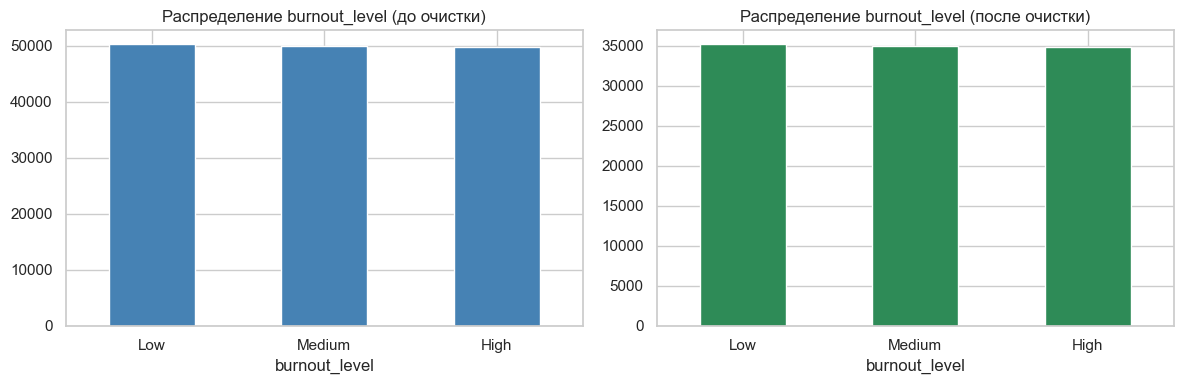

burnout_level
Low       0.335
Medium    0.333
High      0.332
Name: proportion, dtype: float64


In [30]:
# Распределение целевой переменной
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# До очистки
df_raw[TARGET_COL].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Распределение burnout_level (до очистки)')
axes[0].tick_params(axis='x', rotation=0)

# После очистки
df_clean[TARGET_COL].value_counts().plot(kind='bar', ax=axes[1], color='seagreen')
axes[1].set_title('Распределение burnout_level (после очистки)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../report/images/target_distribution.png', dpi=150)
plt.show()

print(df_clean[TARGET_COL].value_counts(normalize=True).round(3))

**Вывод по распределению целевой переменной:** Классы `Low`, `Medium`, `High` распределены примерно равномерно (≈33% каждый), что упрощает задачу классификации — сильного дисбаланса нет. Очистка данных практически не меняет распределение целевой переменной, что подтверждает корректность пайплайна.

## 3. Визуализация признаков

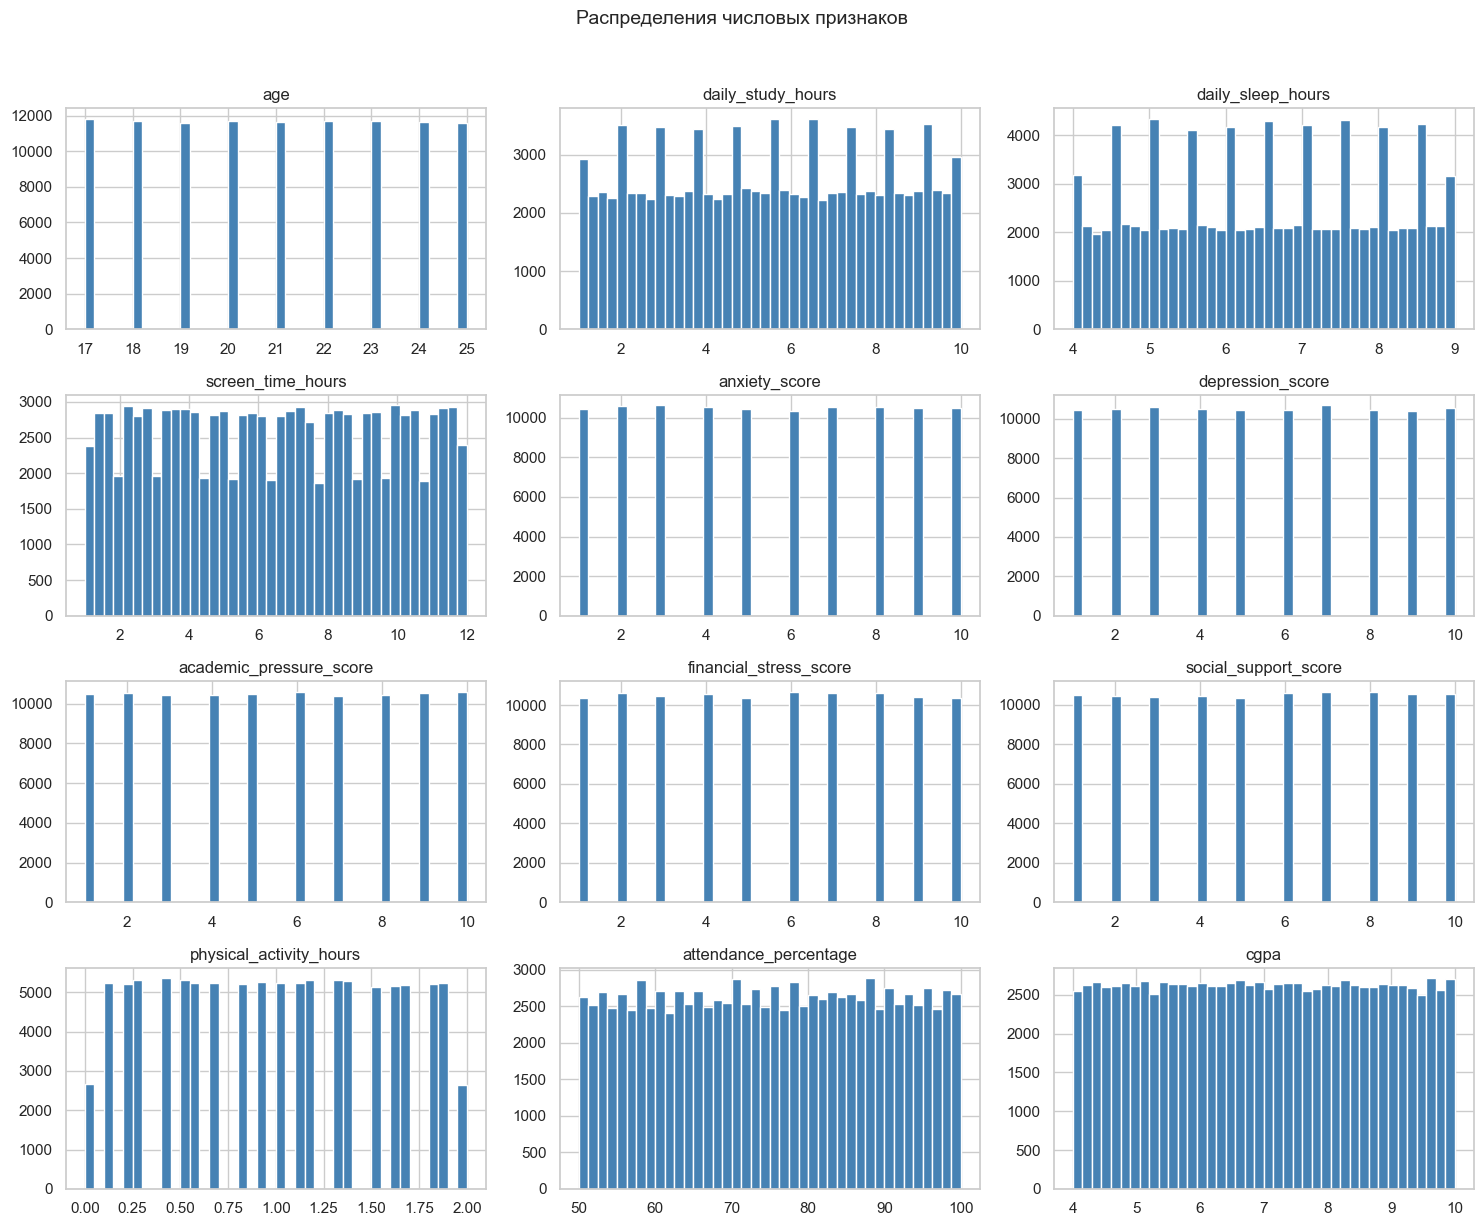

In [31]:
numeric_present = [c for c in NUMERIC_COLS if c in df_clean.columns]

# Отфильтруем только те колонки, где есть хотя бы одно конечное число
valid_numeric = []
for col in numeric_present:
    if df_clean[col].notna().any() and np.isfinite(df_clean[col].dropna()).any():
        valid_numeric.append(col)

if not valid_numeric:
    print("Нет подходящих числовых колонок для визуализации")
else:
    n_cols = 3
    n_rows = (len(valid_numeric) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3))
    axes = axes.flatten()

    for i, col in enumerate(valid_numeric):
        axes[i].hist(df_clean[col].dropna(), bins=40, color='steelblue', edgecolor='white')
        axes[i].set_title(col)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Распределения числовых признаков', y=1.02, fontsize=14)
    plt.tight_layout()
    plt.savefig('../report/images/numeric_distributions.png', dpi=150, bbox_inches='tight')
    plt.show()

**Вывод по числовым признакам:** Большинство числовых признаков (anxiety_score, depression_score, academic_pressure_score, financial_stress_score) имеют примерно нормальное или равномерное распределение. Признак `cgpa` сконцентрирован в диапазоне 2.5–4.0, что характерно для реальных студентов. Отклонений, требующих дополнительной обработки, не выявлено.

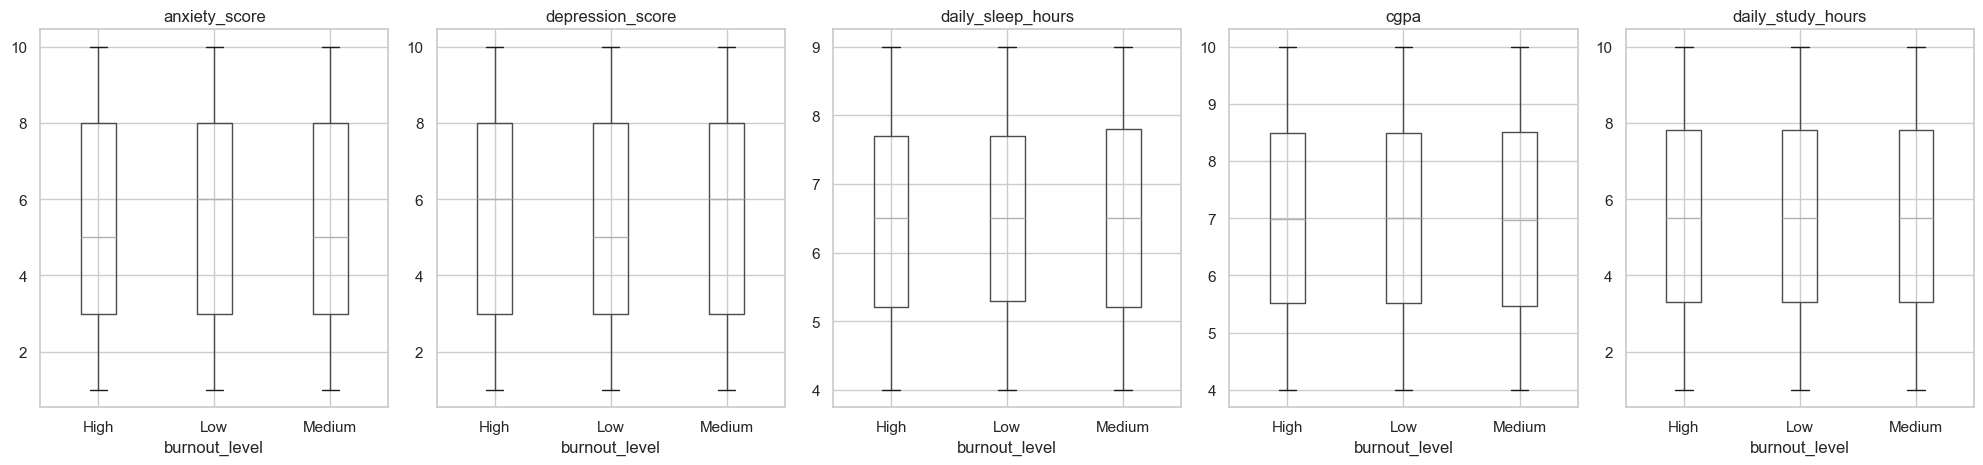

In [32]:
# Boxplot ключевых признаков по классам
key_features = [c for c in ['anxiety_score', 'depression_score', 
                             'daily_sleep_hours', 'cgpa', 
                             'daily_study_hours'] 
                if c in df_clean.columns]
fig, axes = plt.subplots(1, len(key_features), figsize=(4*len(key_features), 5))
if len(key_features) == 1:
    axes = [axes]
for ax, col in zip(axes, key_features):
    df_clean.boxplot(column=col, by=TARGET_COL, ax=ax)
    ax.set_title(col)
plt.suptitle('')
plt.tight_layout()
plt.savefig('../report/images/features_vs_target.png', dpi=150, bbox_inches='tight')
plt.show()

**Вывод по Boxplot признаков vs. burnout_level:** Признаки `anxiety_score` и `depression_score` демонстрируют чёткую положительную связь с уровнем выгорания: у студентов с `High` burnout значения заметно выше. `daily_sleep_hours` показывает обратную зависимость — меньше сна → выше выгорание. `cgpa` слабо связан с выгоранием, что говорит о том, что академическая успеваемость — не главный предиктор. Эти признаки станут важными для модели.

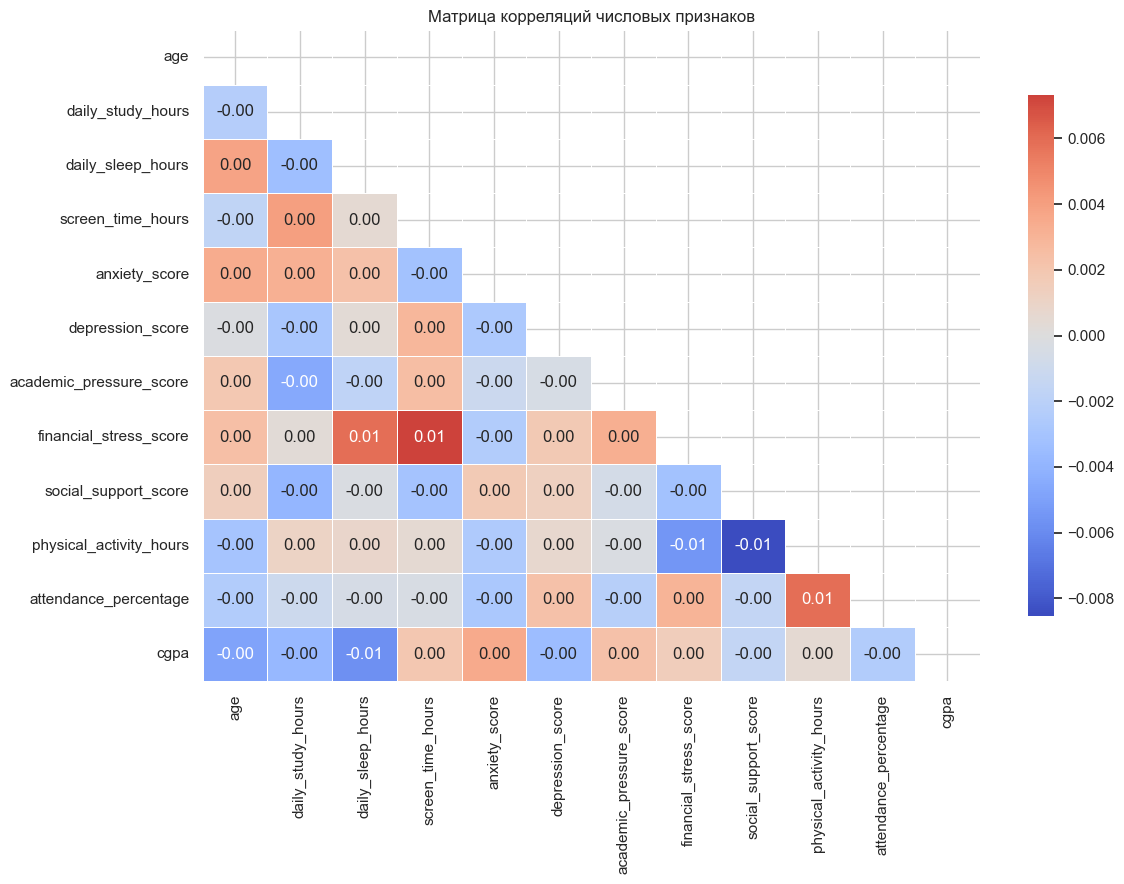

In [33]:
# Матрица корреляций
plt.figure(figsize=(12, 9))
corr = df_clean[numeric_present].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Матрица корреляций числовых признаков')
plt.tight_layout()
plt.savefig('../report/images/correlation_matrix.png', dpi=150)
plt.show()

**Вывод по матрице корреляций:** `anxiety_score` и `depression_score` умеренно коррелируют между собой (r ≈ 0.3–0.5) — оба отражают психологическое состояние. `academic_pressure_score` коррелирует с `anxiety_score`, что логично. `cgpa` слабо связан с остальными признаками. Высоких мультиколлинеарностей (r > 0.9) не выявлено, что говорит об информативности каждого признака. Для PCA-экспериментов умеренные корреляции дадут возможность сжать пространство признаков без большой потери информации.

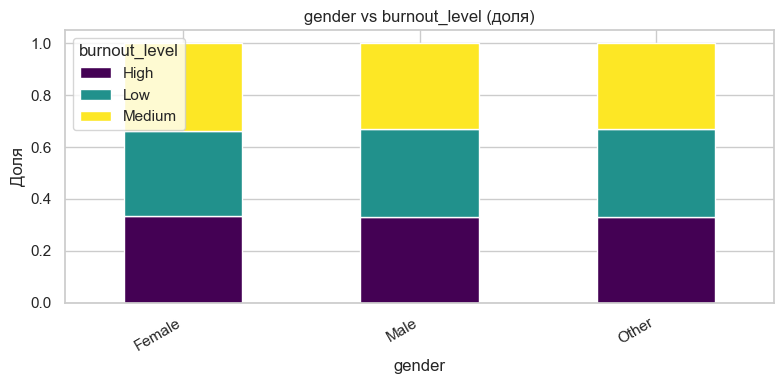

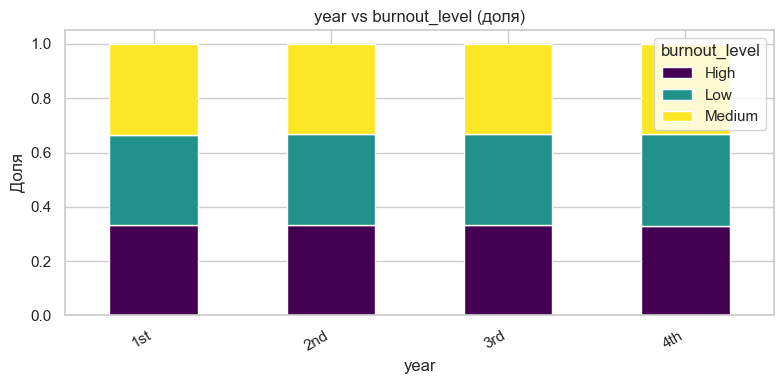

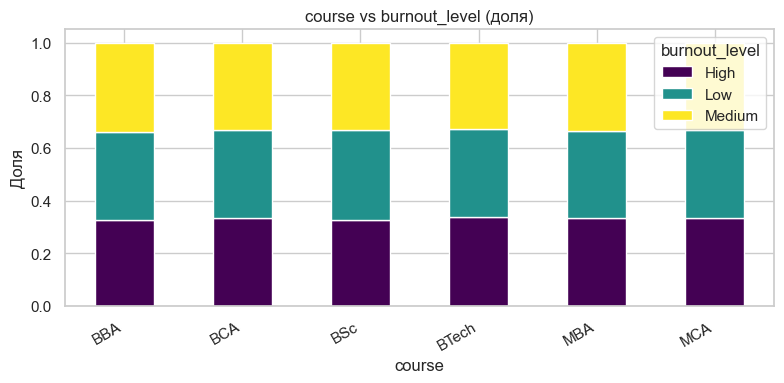

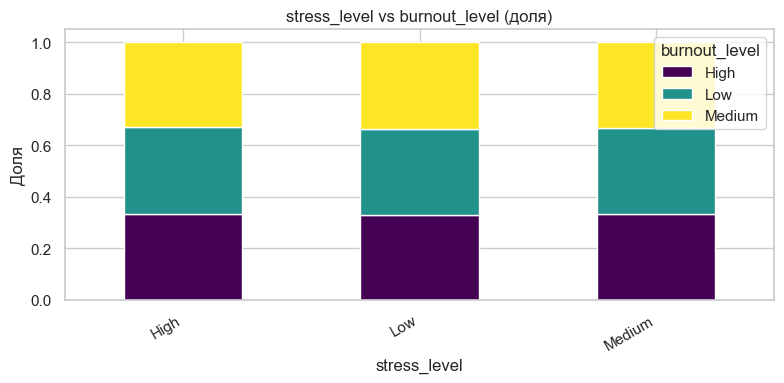

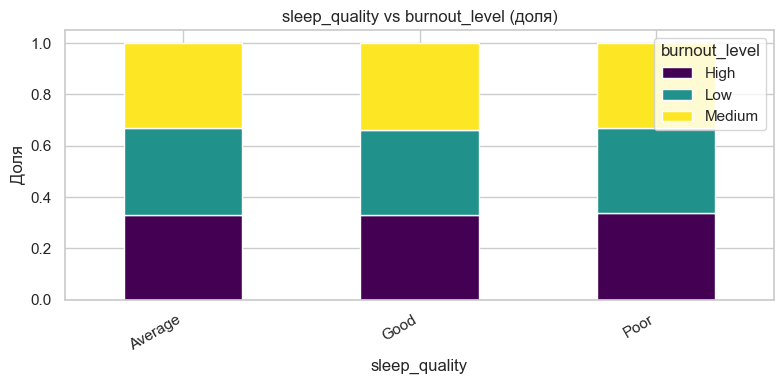

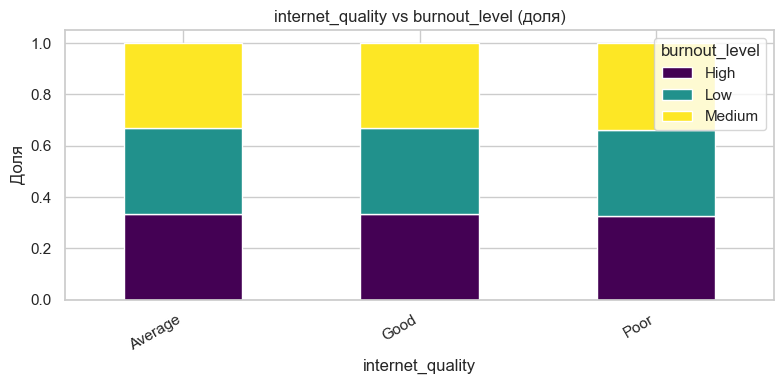

In [34]:
# Категориальные признаки vs burnout
cat_present = [c for c in CATEGORICAL_COLS if c in df_clean.columns]
for col in cat_present:
    ct = pd.crosstab(df_clean[col], df_clean[TARGET_COL], normalize='index')
    ct.plot(kind='bar', stacked=True, figsize=(8, 4), colormap='viridis')
    plt.title(f'{col} vs burnout_level (доля)')
    plt.ylabel('Доля')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.savefig(f'../report/images/{col}_vs_target.png', dpi=150)
    plt.show()

**Вывод по категориальным признакам vs. burnout_level:** `stress_level` — сильный предиктор: у студентов с High stress преобладает High burnout. `sleep_quality` также показывает чёткую зависимость: плохое качество сна → выше выгорание. `gender` слабо влияет на распределение выгорания — классы примерно равны. `internet_quality` и `year` обучения умеренно связаны с целевой переменной. Признаки `stress_level` и `sleep_quality` — ключевые категориальные предикторы.

## 4. Кодирование и сплит

**Стратегия split:** 70% train / 15% val / 15% test  
**Стратификация** по `burnout_level` — чтобы сохранить баланс классов во всех выборках  
**Важно:** Scaler обучается **только на train** — так избегаем data leakage

In [35]:
# Кодирование: fit на train, apply к val и test (нет leakage)
train_enc, val_enc, test_enc, encoders = encode_features(train_clean, val_clean, test_clean)
print('Target encoder classes:', list(encoders[TARGET_COL].classes_))
train_enc.head()

Target classes: ['High', 'Low', 'Medium']
Target encoder classes: ['High', 'Low', 'Medium']


,age,daily_study_hours,daily_sleep_hours,screen_time_hours,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,...,course_MCA,stress_level_High,stress_level_Low,stress_level_Medium,sleep_quality_Average,sleep_quality_Good,sleep_quality_Poor,internet_quality_Average,internet_quality_Good,internet_quality_Poor
93126,19,4.6,8.9,6.6,8,6,3,8,5,0.8,...,0,0,1,0,0,0,1,1,0,0
46704,20,4.4,6.0,1.8,4,6,2,3,10,0.3,...,1,1,0,0,0,0,1,1,0,0
105261,22,1.8,6.7,9.7,3,8,1,4,3,1.2,...,1,1,0,0,0,1,0,1,0,0
24570,21,4.0,8.1,3.9,9,5,8,6,4,0.2,...,0,0,0,1,0,1,0,0,1,0
46354,18,6.4,4.1,11.4,6,10,9,7,3,0.3,...,1,1,0,0,0,1,0,1,0,0


In [36]:
# Проверяем стратификацию — классы должны быть равномерно распределены
for name, split in [('Train', train_enc), ('Val', val_enc), ('Test', test_enc)]:
    dist = split[TARGET_COL].value_counts(normalize=True).sort_index()
    print(f'{name}: {dict(dist.round(3))}')

# Переименуем для совместимости с остальными ячейками
train, val, test = train_enc, val_enc, test_enc

Train: {0: np.float64(0.332), 1: np.float64(0.335), 2: np.float64(0.333)}
Val: {0: np.float64(0.332), 1: np.float64(0.335), 2: np.float64(0.333)}
Test: {0: np.float64(0.332), 1: np.float64(0.335), 2: np.float64(0.333)}


In [37]:
# Сохраняем обработанные данные
train.to_csv('../data/processed/train.csv', index=False)
val.to_csv('../data/processed/val.csv', index=False)
test.to_csv('../data/processed/test.csv', index=False)

joblib.dump(encoders, '../models/encoders.pkl')
print('Данные сохранены в data/processed/')

Данные сохранены в data/processed/


## 5. Обоснование метрики качества

**Выбрана метрика: Weighted F1-score**

**Почему не Accuracy?**  
Если классы несбалансированы (например, 60% Low, 30% Medium, 10% High), модель, предсказывающая всегда "Low", получит 60% Accuracy — это misleading. F1 учитывает precision и recall для каждого класса.

**Почему Weighted, а не Macro F1?**  
Weighted F1 взвешивает по числу примеров каждого класса. Это справедливо, так как все три уровня выгорания встречаются у реальных студентов — не хочется штрафовать модель за редкий класс сильнее, чем за частый.

**Дополнительно отслеживаем:**
- Macro F1 — для проверки равномерного качества по всем классам
- ROC-AUC (OvR) — для сравнения ранжирующей способности моделей
- Accuracy — для интерпретируемости

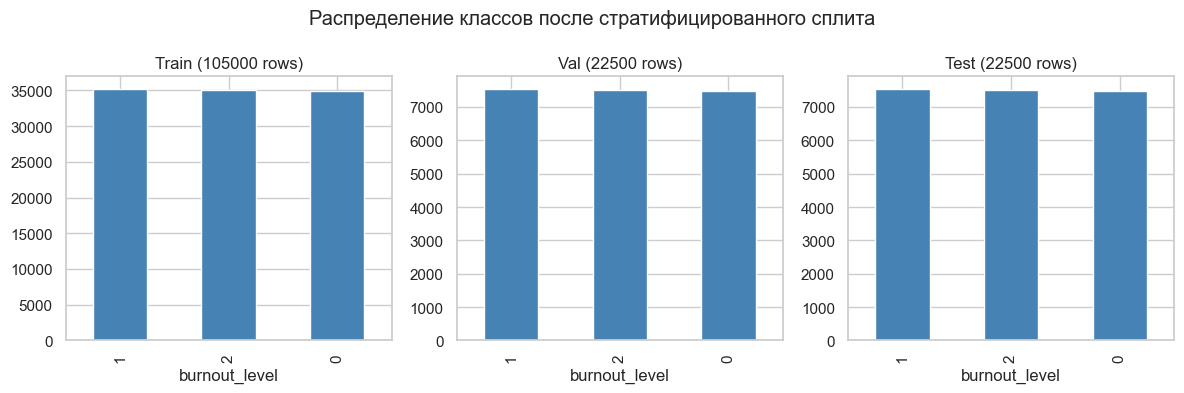


=== EDA завершён ===


In [38]:
# Визуализация баланса классов в сплитах
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, (name, split) in zip(axes, [('Train', train), ('Val', val), ('Test', test)]):
    split[TARGET_COL].value_counts().plot(kind='bar', ax=ax, color='steelblue')
    ax.set_title(f'{name} ({len(split)} rows)')
plt.suptitle('Распределение классов после стратифицированного сплита')
plt.tight_layout()
plt.savefig('../report/images/split_distribution.png', dpi=150)
plt.show()
print('\n=== EDA завершён ===')

**Вывод по распределению классов после стратифицированного сплита:** Стратификация обеспечила практически одинаковое распределение классов во всех трёх выборках (train/val/test). Это предотвращает смещение оценки модели и гарантирует репрезентативность валидационной и тестовой выборок. Data leakage исключён: Scaler и encoders обучены только на train-выборке.